# Greath North Run data processing

In [10]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
raw_df = pd.read_excel("2024 Data Challenge Raw Data.xlsx")
raw_df.shape

(14614, 17)

## Row descriptions
|Variable |	Definition |
| :-: | :- |
| club |	The club the runner is a part of 
|position |	The position the runner finished in 
|time |	The time the runner took to finish the race
|id |	The runners id
|gender	| The runners gender
|trained_10_week |	The average number of times per week the runner trained 10 or more weeks ago
|trained_im	| The average number of times per week the runner trained less than e weeks ago
|has_trainer |	Whether the runner has a trainer or not
|cadence |	The average number of steps the runner took per minute
|age |	The age of the runner
|bmi |	The bmi of the runner
|n_marathons_run |	The number of marathons the runner has run before the race
|bib_colour |	The runners bib colour
|VO2_max |	The VO2 max of the runner
|heart_rate	| The resting heart rate of the runner
|shoe_size	| The runner's shoe size


NOTE:  
*Bib colours have meaning:  
Orange: 

In [12]:
raw_df.head()

#figure out unnamed column name- external sources?
#fix club names for all the records, fill up until you find text

,Unnamed: 0,club,position,time,id,gender,trained_10_week,trained_im,has_trainer,cadence,age,bmi,n_marathons_run,bib_colour,VO2_max,heart_rate,shoe_size
0,7448,NaN,14589,03:45:46,7426,female,0.789725,0.789725,0,163,36.0,999.00,0.0,green,12.718323,103.67,6
1,5363,NaN,14588,03:26:28,5345,female,1.670838,1.670838,0,157,30.0,19.05,0.0,green,12.718323,99.33,5
2,11420,NaN,14587,03:26:22,11387,female,1.917839,1.917839,0,165,38.0,21.13,0.0,green,13.460000,98.43,6
3,9408,Gump's training,14586,03:21:13,9384,male,0.000000,0.000000,0,154,38.0,18.86,0.0,green,20.010000,100.91,7
4,6604,NaN,14585,03:20:19,6585,female,0.000000,0.710092,0,166,43.0,19.75,0.0,green,12.718323,102.45,6


In [13]:
#no of missing values in each column 
raw_df.isnull().sum()

Unnamed: 0             0
club               11425
position               0
time                  47
id                     0
gender                 0
trained_10_week       74
trained_im           151
has_trainer            0
cadence                0
age                   51
bmi                    0
n_marathons_run       37
bib_colour             0
VO2_max              572
heart_rate           550
shoe_size              0
dtype: int64

In [14]:
raw_df.describe()

,Unnamed: 0,position,id,trained_10_week,trained_im,has_trainer,cadence,age,bmi,n_marathons_run,VO2_max,heart_rate,shoe_size
count,14614.000000,14614.000000,14614.000000,14540.000000,14463.000000,14614.000000,14614.000000,14563.000000,14614.000000,14577.000000,14042.000000,14064.000000,14614.000000
mean,7328.758656,7280.848159,7306.500000,-3.083608,-8.237465,0.078692,159.093540,36.102383,60.647316,3084.041984,44.585019,81.290607,7.656631
std,4231.313944,4219.205169,4218.842752,75.482450,106.119666,0.269266,32.010322,9.891467,189.231907,54865.742122,19.961066,10.775136,3.041907
min,0.000000,1.000000,0.000000,-999.000000,-999.000000,0.000000,1.000000,18.000000,15.050000,-9.000000,10.010000,58.680000,3.000000
25%,3665.250000,3627.250000,3653.250000,1.183613,2.008240,0.000000,161.000000,30.000000,21.120000,3.000000,28.260000,72.207500,5.000000
50%,7328.500000,7280.500000,7306.500000,2.745488,3.251724,0.000000,165.000000,36.000000,22.610000,6.000000,43.280000,80.740000,7.000000
75%,10992.750000,10933.750000,10959.750000,4.023773,4.332161,0.000000,169.000000,42.000000,24.180000,11.000000,60.827500,89.952500,10.000000
max,14660.000000,14589.000000,14613.000000,6.919653,6.919653,1.000000,189.000000,83.000000,999.000000,1000000.000000,95.850000,114.830000,13.000000


In [15]:

print(raw_df.bib_colour.value_counts())

bib_colour
green     5785
blue      4397
yellow    2925
red       1507
Name: count, dtype: int64


In [24]:
raw_df.columns
raw_df.dropna(subset=['time'], inplace=True)
raw_df['time_seconds'] = pd.to_timedelta(raw_df['time']).dt.total_seconds().astype(int)

# Make a copy so we don't accidentally alter the original
data = raw_df.copy()

# Remove the automatically-created index column if it isn't useful
data = data.drop(columns=["Unnamed: 0"], errors="ignore")
data["time_hours"] = data["time_seconds"] / 3600


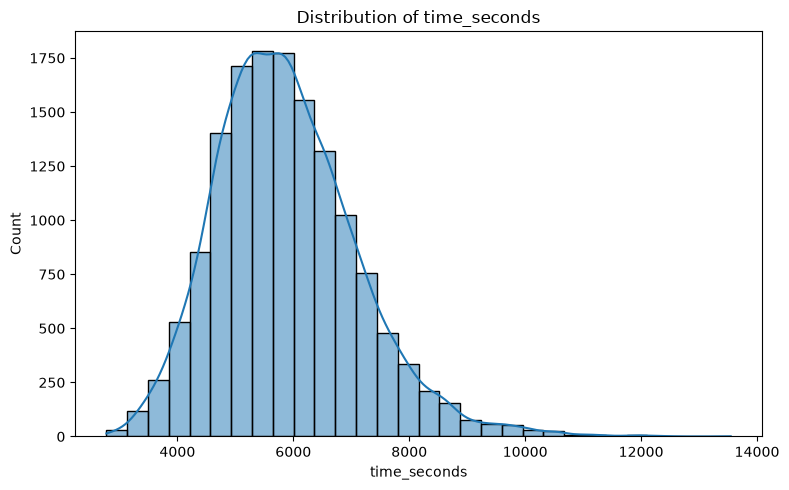

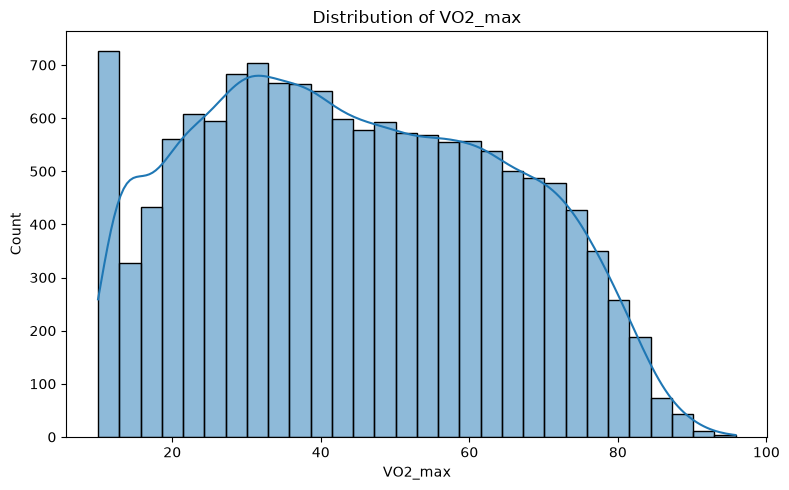

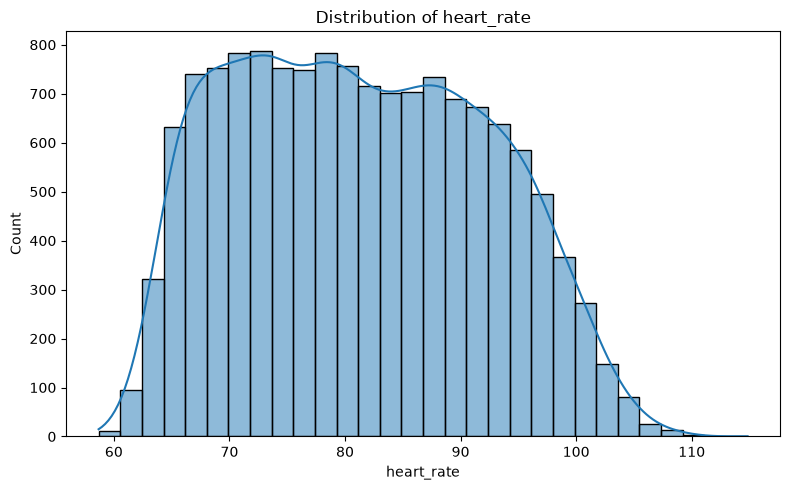

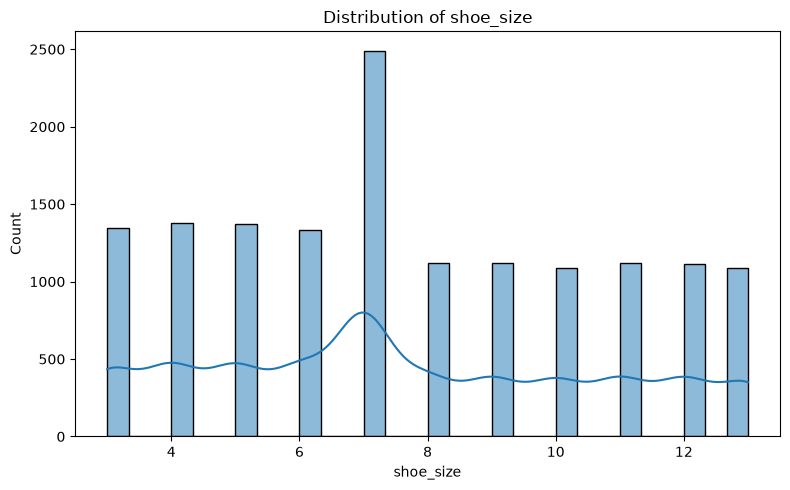

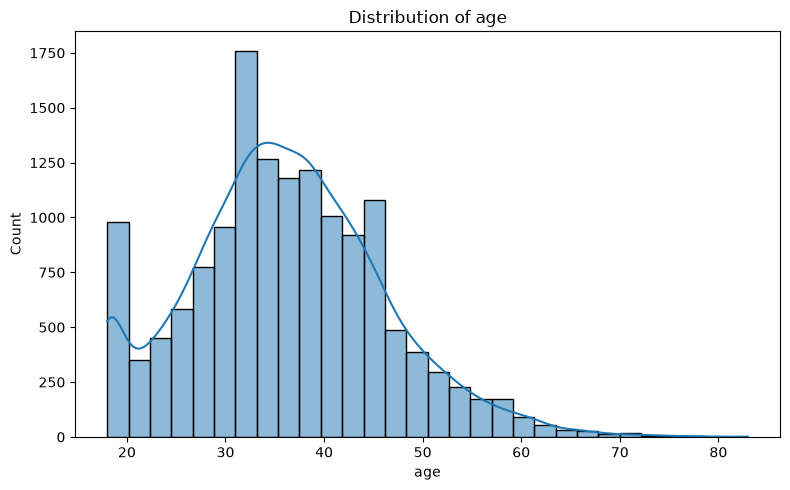

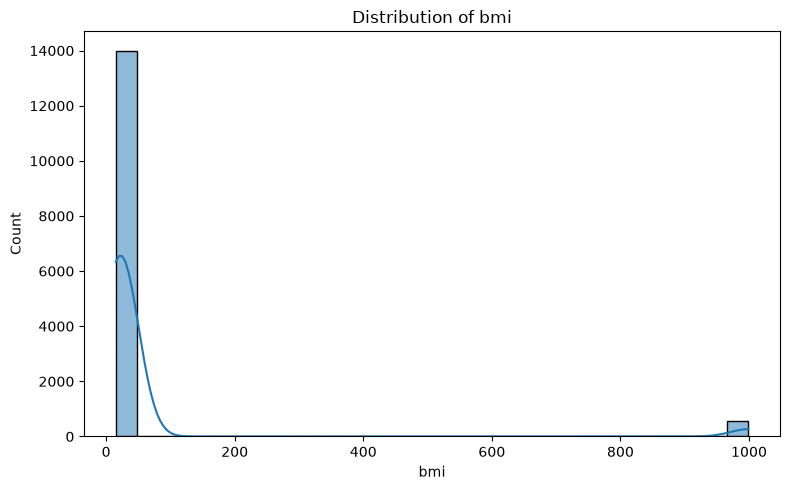

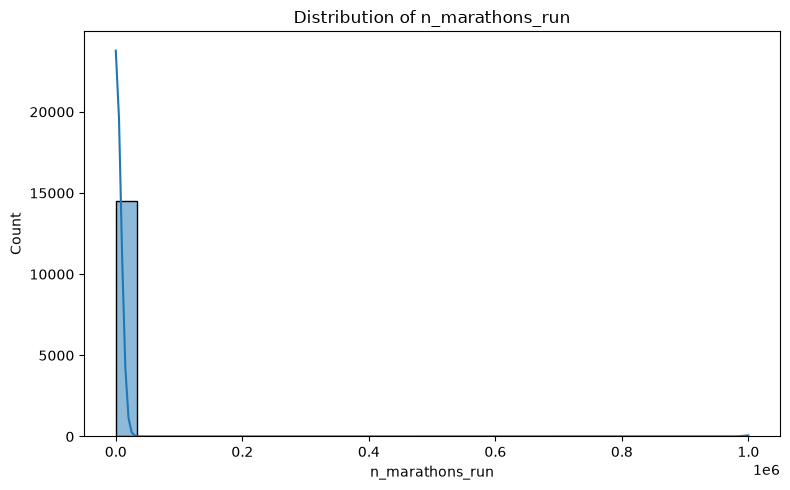

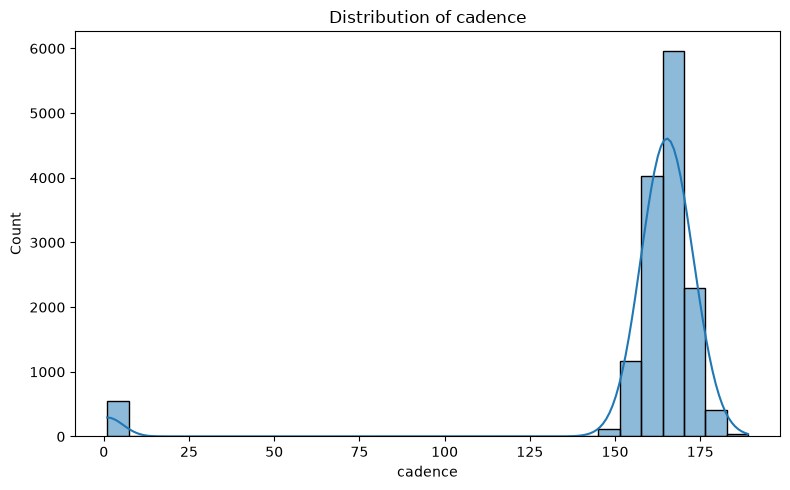

In [22]:
# distribution plots for all numerical
numeric_cols = [
    "time_seconds",
    "VO2_max",
    "heart_rate",
    "shoe_size",
    "age",
    "bmi",
    "n_marathons_run",
    "cadence"
]

for col in numeric_cols:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=data,
        x=col,
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()


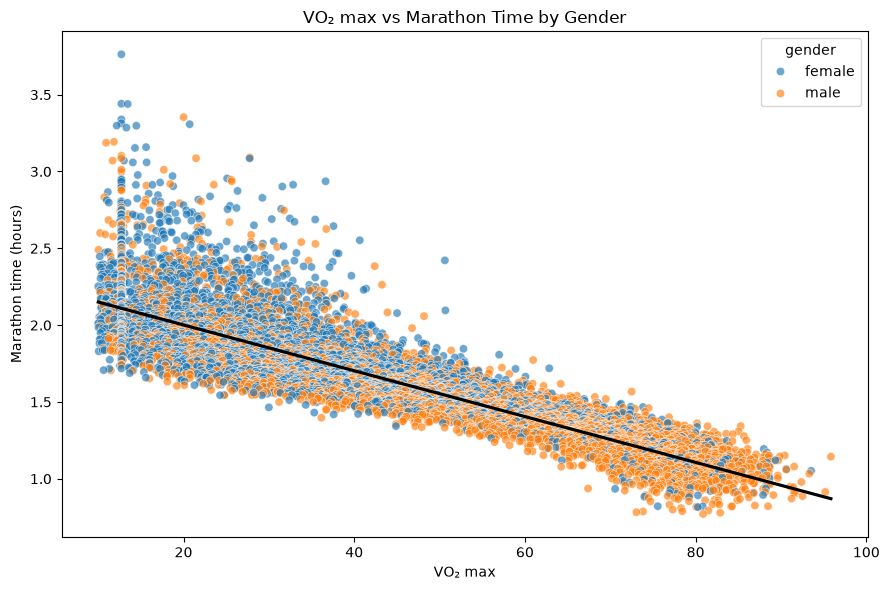

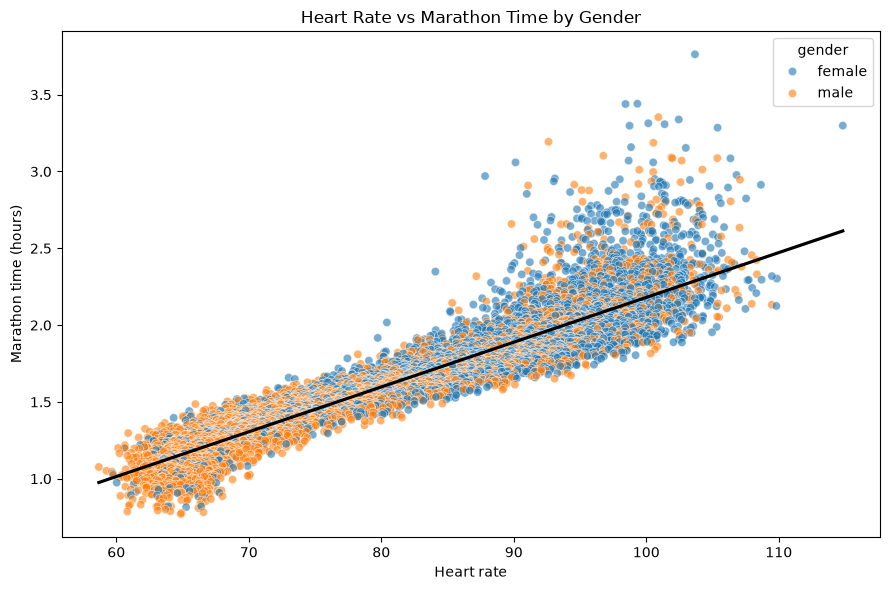

In [27]:
# vo2 and heart rate by gender by time
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=data,
    x="VO2_max",
    y="time_hours",
    hue="gender",
    alpha=0.65
)

sns.regplot(
    data=data,
    x="VO2_max",
    y="time_hours",
    scatter=False,
    color="black"
)

plt.xlabel("VO₂ max")
plt.ylabel("Marathon time (hours)")
plt.title("VO₂ max vs Marathon Time by Gender")

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=data,
    x="heart_rate",
    y="time_hours",
    hue="gender",
    alpha=0.6
)

sns.regplot(
    data=data,
    x="heart_rate",
    y="time_hours",
    scatter=False,
    color="black"
)

plt.xlabel("Heart rate")
plt.ylabel("Marathon time (hours)")
plt.title("Heart Rate vs Marathon Time by Gender")

plt.tight_layout()
plt.show()


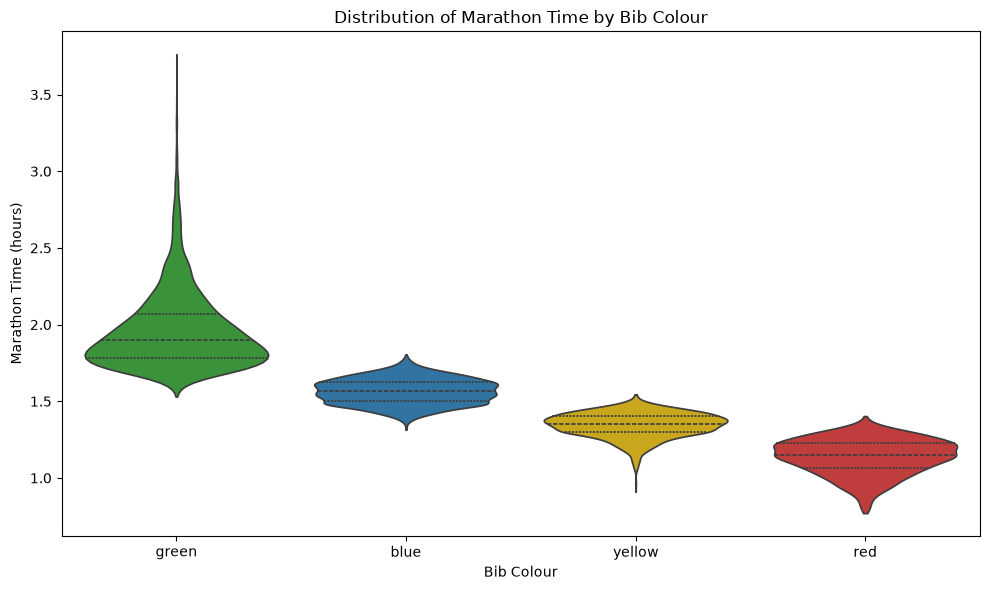

In [31]:
# bib colour clusters

# Define colours for each bib colour
bib_colors = {
    "red": "#D62728",
    "blue": "#1F77B4",
    "green": "#2CA02C",
    "yellow": "#E6B800",   # golden yellow
}

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=data,
    x="bib_colour",
    y="time_hours",
    hue="bib_colour",
    palette=bib_colors,
    inner="quartile",
    cut=0,
    legend=False
)

plt.xlabel("Bib Colour")
plt.ylabel("Marathon Time (hours)")
plt.title("Distribution of Marathon Time by Bib Colour")

plt.tight_layout()
plt.show()


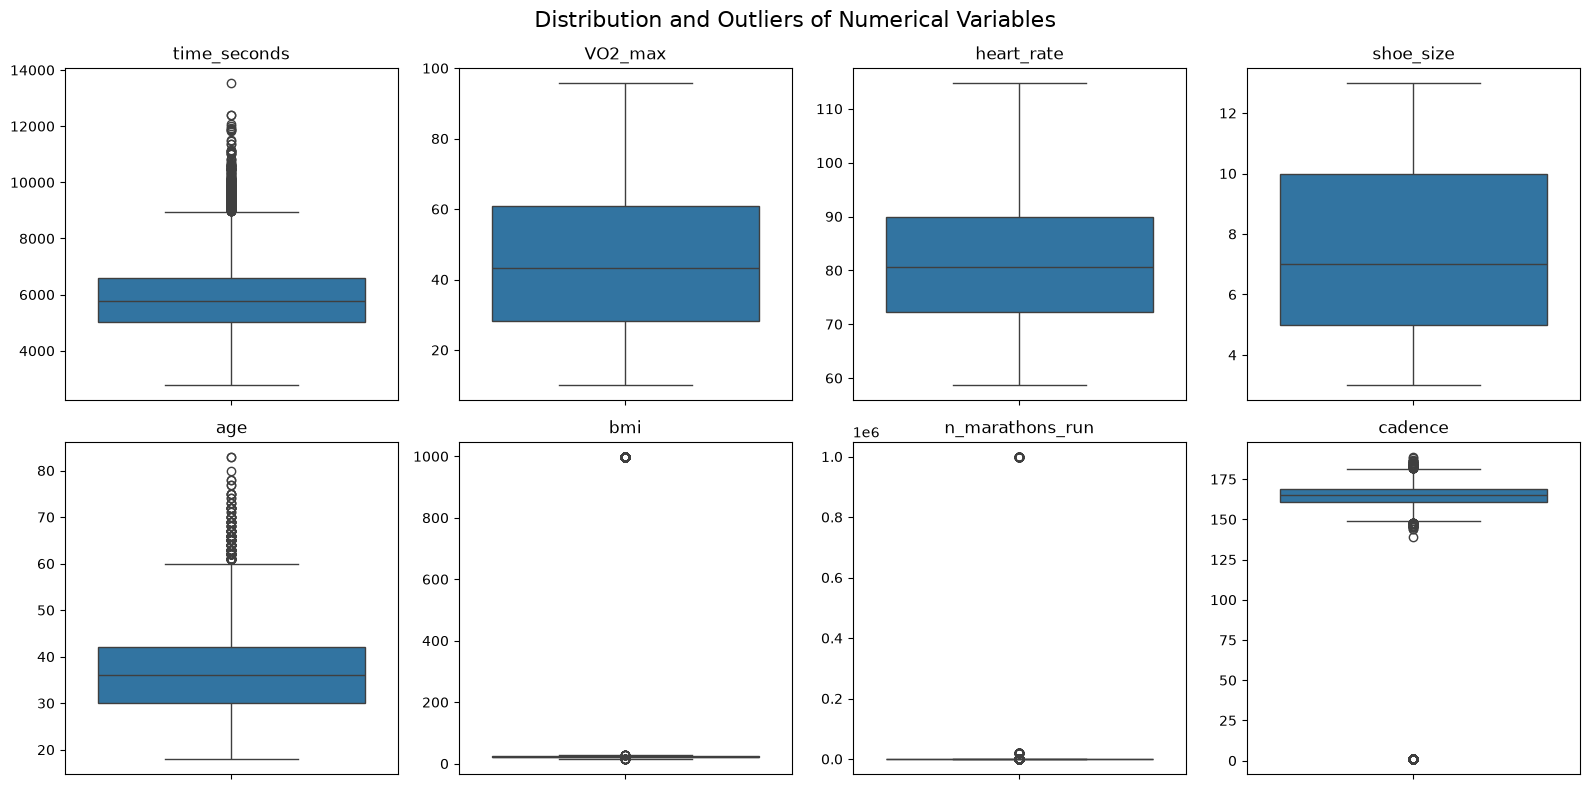

In [35]:
# showing outliers

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(
        data=data,
        y=col,
        ax=ax
    )

    ax.set_title(col)
    ax.set_ylabel("")

plt.suptitle(
    "Distribution and Outliers of Numerical Variables",
    fontsize=16
)

plt.tight_layout()
plt.show()


In [33]:
prin

NameError: name 'prin' is not defined

In [ ]:
# Cleaning steps
# [x] remove non existant: position, id, final time
# [x] trained_10_week & trained_im: replace negative with zero
# [x] has_trainer: one hot (already one hot)
# [x] bib colour: one hot
# [x] bmi: remove outliers
# [x] n_runs: remove negative and outliers
# [x] sex: one hot
df = raw_df

if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)
    # Source - https://stackoverflow.com/a/49554761
    # Posted by Adil Warsi, modified by community. See post 'Timeline' for change history
    # Retrieved 2026-09-22, License - CC BY-SA 4.0
    df.drop(df.columns[df.columns.str.contains('unnamed',case = False)],axis = 1, inplace = True)
df.dropna(subset=['time'], inplace=True)
df['time'] = pd.to_timedelta(df['time']).dt.total_seconds().astype(int)

# clean missing and negative values
df['trained_10_week'] = df['trained_10_week'].mask(df['trained_10_week'] < 0, 0)
df['trained_10_week'] = df['trained_10_week'].mask(df['trained_10_week'].isna(), 0)
df['trained_im'] = df['trained_im'].mask(df['trained_im'] < 0, 0)
df['trained_im'] = df['trained_im'].mask(df['trained_im'].isna(), 0)

# missing, negative and outliers
df['n_marathons_run'] = df['n_marathons_run'].mask(df['n_marathons_run'] < 0, 0)
df['n_marathons_run'] = df['n_marathons_run'].mask(df['n_marathons_run'].isna(), 0)
df['n_marathons_run'] = df.drop(df['n_marathons_run'] > 50)

# multi hot encoding
df['bib_colour_multi'], _ = pd.factorize(df['bib_colour'])
df['gender_multi'], _ = pd.factorize(df['gender'])

bmi_outliers = df['bmi'] == 999.0
print(bmi_outliers.value_counts())  # about 568 such cases so there is data error
df['bmi'] = df['bmi'].mask(df['bmi'] == 999.0, df['bmi'].mean())

# drop missing values cause they have strong correlation
df.dropna(subset=['VO2_max', 'heart_rate'])

# drop rows for people who have run more than =1000 marathons 
df = df.drop(df[df["n_marathons_run"] >= 700].index)
df.describe()

In [ ]:
df.head()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Define your exact list of columns
columns = [
    "position",
    "time_seconds",
    "trained_10_week",
    "trained_im",
    "has_trainer",
    "cadence",
    "age",
    "bmi",
    "n_marathons_run",
    "VO2_max",
    "heart_rate",
    "shoe_size",
    "bib_colour_multi",
    "gender_multi",
]

# 2. Compute the Pearson correlation matrix on your DataFrame
corr = df[columns].corr(method="pearson")

# 3. Generate a boolean mask for the upper triangle
# This hides the redundant mirror reflection and keeps the plot clean
mask = np.triu(np.ones_like(corr, dtype=bool))

# 4. Set up the matplotlib figure size (larger to fit all 14 variables)
plt.figure(figsize=(14, 12))

# 5. Plot the triangular heatmap
sns.heatmap(
    corr,
    mask=mask,
    annot=True,  # Displays numbers inside the squares
    fmt=".2f",  # Rounds visual annotations to 2 decimal places
    cmap="coolwarm",  # Red for positive correlation, blue for negative
    vmin=-1,
    vmax=1,  # Standardizes the color scale limits
    square=True,  # Forces cells to be perfect squares
    linewidths=0.5,  # Adds clean white borders between cells
    cbar_kws={"shrink": 0.8},  # Shrinks colorbar slightly for visual balance
)

# 6. Add a title and tweak layout so labels don't get cut off
plt.title("Running Dataset: Pearson Correlation Matrix", fontsize=16, pad=20)
plt.tight_layout()
plt.show()


#Since there is a very strong correlation between the VO2_max and heart_rate, populating it with an average will affect the reliabilioty of the model to accurately predict the performance of a runner, and since the unique number of rows with the intersection of both these values is less than 10% of the data, we have chosen to eliminate it


In [ ]:
(df["bib_colour"][df["cadence"] == 1.00000]).value_counts()

In [ ]:

average_timings = df.groupby(['bib_colour', 'gender'])['time'].mean().reset_index()
average_timings.columns = ['Bib Color', 'Gender', 'Average Seconds']

# 2. Convert the average seconds into HH:MM:SS format
average_timings['Average HH:MM:SS'] = pd.to_timedelta(average_timings['Average Seconds'].round(), unit='s')
average_timings['Average HH:MM:SS'] = average_timings['Average HH:MM:SS'].apply(lambda x: str(x).split()[-1])

print(average_timings)

In [ ]:
# a.
# - clean and why you clean what you clean
# - mean, std, min, max, basically .describe()
# - yap about distribution (maybe pair plot)

# b.
# - pearson correlation matrix

# c.
# get rid of position
# inc VO2_max, heart rate, times trained both variables, bib colour, n_marathons_run (mandatory)
# gender